## Setup & Installation

In [1]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import string

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

## Load Data

In [2]:
df_train = pd.read_csv("../../data/cleaned/crawl_only_train.csv")
df_val = pd.read_csv("../../data/cleaned/crawl_only_val.csv")
df_test = pd.read_csv("../../data/cleaned/crawl_only_test.csv")

print("="*30 + " Training Set " + "="*30)
print(f"Dataset shape: {df_train.shape}")
print("First 5 rows:")
display(df_train.head(5))

print("="*30 + " Validation Set " + "="*30)
print(f"Dataset shape: {df_val.shape}")
print("First 5 rows:")
display(df_val.head(5))

print("="*30 + " Test Set " + "="*30)
print(f"Dataset shape: {df_test.shape}")
print("First 5 rows:")
display(df_test.head(5))

============================== Training Set ==============================
Dataset shape: (13224, 9)
First 5 rows:


,review_id,Review,rating,vệ sinh_label,đồ ăn thức uống_label,khách sạn_label,vị trí_label,phòng ốc_label,dịch vụ_label
0,834149749,phòng nhỏ gia_đình mình check out sớm để lại v...,5.0,0,0,2,0,2,2
1,344704376,vợ_chồng tôi ở đây một đêm trước khi đi hội_an...,10.0,1,0,1,0,1,1
2,920704244,dịch_vụ tốt nha em ơi,10.0,0,0,1,0,0,0
3,646347967,chỗ này oai lắm nhé gần biển đi ra có 5 mình l...,8.0,1,0,0,1,0,0
4,920709757,rất thoải_mái và nhân_viên tuyệt_vời,10.0,0,0,1,0,0,1


============================== Validation Set ==============================
Dataset shape: (3778, 9)
First 5 rows:


,review_id,Review,rating,vệ sinh_label,đồ ăn thức uống_label,khách sạn_label,vị trí_label,phòng ốc_label,dịch vụ_label
0,192799697,phòng rộng_rãi và sạch_sẽ áp_lực nước yếu và n...,7.0,2,2,0,0,1,0
1,235618058,căn_hộ mới và rất ấm_cúng tôi vô_cùng yêu thíc...,10.0,0,0,1,0,1,0
2,1073406742,phòng_không có cửa_sổ tối_om và tệ hơn_nữa là ...,4.0,0,0,0,0,2,0
3,770838987,phòng ok đẹp nằm trong hẻm,9.0,0,0,0,0,1,0
4,165720311,phòng bí không dọn phòng tuy_nhiên cô chủ thân...,4.0,2,0,0,0,2,1


============================== Test Set ==============================
Dataset shape: (1889, 9)
First 5 rows:


,review_id,Review,rating,vệ sinh_label,đồ ăn thức uống_label,khách sạn_label,vị trí_label,phòng ốc_label,dịch vụ_label
0,781743501,khi đến đà_nẵng tôi đã đặt phòng tại một khách...,10.0,0,1,0,1,0,1
1,588010174,đây là một khách_sạn gần bãi biển ở đà_nẵng ôn...,10.0,1,0,1,1,0,1
2,1282987,khách_sạn nằm gần các nhà hàg và tiện_nghi khá...,7.0,0,0,1,1,1,1
3,252204885,khách_sạn rất thoải_mái và nhân_viên thân_thiệ...,10.0,0,0,1,1,0,0
4,1073778252,cảnh_quan thì tuyệt_vời nhưng thái_độ của cô l...,8.0,0,0,1,0,0,2


## Data structure, missing values and deduplicate check

### Training Set

In [3]:
review_col = "Review" if "Review" in df_train.columns else df_train.select_dtypes(include="object").columns[0]
rating_col = "rating"
aspect_cols = [c for c in df_train.columns if c.endswith("_label")]

print("="*30 + " Dataset Columns " + "="*30)
print(f"Number of aspect label columns: {len(aspect_cols)}")
print("Aspect label columns:")
for col in aspect_cols:
    print(f"- {col}")

print("="*30 + " Checking for duplicated rows " + "="*30)
dup_mask = df_train.duplicated()
has_duplicate = bool(dup_mask.any())
dup_count = int(dup_mask.sum())
print(f"Has duplicated rows: {has_duplicate}")
print(f"Number of duplicated rows: {dup_count}")


missing_stats = (
    df_train.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df_train) * 100).round(3))
    .sort_values("missing_count", ascending=False)
)

print("="*30 + " Missing value statistics " + "="*30)
display(missing_stats)

print("="*30 + " Max and min token counts in reviews " + "="*30)
df_train["token_count"] = df_train[review_col].apply(lambda x: len(str(x).split()))
print(f"Max token count: {df_train['token_count'].max()}")
print(f"Min token count: {df_train['token_count'].min()}")
print(f"Average token count: {df_train['token_count'].mean():.2f}")

============================== Dataset Columns ==============================
Number of aspect label columns: 6
Aspect label columns:
- vệ sinh_label
- đồ ăn thức uống_label
- khách sạn_label
- vị trí_label
- phòng ốc_label
- dịch vụ_label
============================== Checking for duplicated rows ==============================
Has duplicated rows: False
Number of duplicated rows: 0
============================== Missing value statistics ==============================


,missing_count,missing_pct
review_id,0,0.0
Review,0,0.0
rating,0,0.0
vệ sinh_label,0,0.0
đồ ăn thức uống_label,0,0.0
khách sạn_label,0,0.0
vị trí_label,0,0.0
phòng ốc_label,0,0.0
dịch vụ_label,0,0.0


============================== Max and min token counts in reviews ==============================
Max token count: 205
Min token count: 3
Average token count: 30.99


### Validation Set

In [4]:
review_col = "Review" if "Review" in df_val.columns else df_val.select_dtypes(include="object").columns[0]
rating_col = "rating"
aspect_cols = [c for c in df_val.columns if c.endswith("_label")]

print("="*30 + " Dataset Columns " + "="*30)
print(f"Number of aspect label columns: {len(aspect_cols)}")
print("Aspect label columns:")
for col in aspect_cols:
    print(f"- {col}")


print("="*30 + " Checking for duplicated rows " + "="*30)
dup_mask = df_val.duplicated()
has_duplicate = bool(dup_mask.any())
dup_count = int(dup_mask.sum())
print(f"Has duplicated rows: {has_duplicate}")
print(f"Number of duplicated rows: {dup_count}")

missing_stats = (
    df_val.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df_val) * 100).round(3))
    .sort_values("missing_count", ascending=False)
)

print("="*30 + " Missing value statistics " + "="*30)
display(missing_stats)

print("="*30 + " Max and min token counts in reviews " + "="*30)
df_val["token_count"] = df_val[review_col].apply(lambda x: len(str(x).split()))
print(f"Max token count: {df_val['token_count'].max()}")
print(f"Min token count: {df_val['token_count'].min()}")
print(f"Average token count: {df_val['token_count'].mean():.2f}")

============================== Dataset Columns ==============================
Number of aspect label columns: 6
Aspect label columns:
- vệ sinh_label
- đồ ăn thức uống_label
- khách sạn_label
- vị trí_label
- phòng ốc_label
- dịch vụ_label
============================== Checking for duplicated rows ==============================
Has duplicated rows: False
Number of duplicated rows: 0
============================== Missing value statistics ==============================


,missing_count,missing_pct
review_id,0,0.0
Review,0,0.0
rating,0,0.0
vệ sinh_label,0,0.0
đồ ăn thức uống_label,0,0.0
khách sạn_label,0,0.0
vị trí_label,0,0.0
phòng ốc_label,0,0.0
dịch vụ_label,0,0.0


============================== Max and min token counts in reviews ==============================
Max token count: 200
Min token count: 3
Average token count: 31.28


### Test Set

In [5]:
review_col = "Review" if "Review" in df_test.columns else df_test.select_dtypes(include="object").columns[0]
rating_col = "rating"
aspect_cols = [c for c in df_test.columns if c.endswith("_label")]

print("="*30 + " Dataset Columns " + "="*30)
print(f"Number of aspect label columns: {len(aspect_cols)}")
print("Aspect label columns:")
for col in aspect_cols:
    print(f"- {col}")

print("="*30 + " Checking for duplicated rows " + "="*30)
dup_mask = df_test.duplicated()
has_duplicate = bool(dup_mask.any())
dup_count = int(dup_mask.sum())
print(f"Has duplicated rows: {has_duplicate}")
print(f"Number of duplicated rows: {dup_count}")


missing_stats = (
    df_test.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df_test) * 100).round(3))
    .sort_values("missing_count", ascending=False)
)

print("="*30 + " Missing value statistics " + "="*30)
display(missing_stats)

print("="*30 + " Max and min token counts in reviews " + "="*30)
df_test["token_count"] = df_test[review_col].apply(lambda x: len(str(x).split()))
print(f"Max token count: {df_test['token_count'].max()}")
print(f"Min token count: {df_test['token_count'].min()}")
print(f"Average token count: {df_test['token_count'].mean():.2f}")

============================== Dataset Columns ==============================
Number of aspect label columns: 6
Aspect label columns:
- vệ sinh_label
- đồ ăn thức uống_label
- khách sạn_label
- vị trí_label
- phòng ốc_label
- dịch vụ_label
============================== Checking for duplicated rows ==============================
Has duplicated rows: False
Number of duplicated rows: 0
============================== Missing value statistics ==============================


,missing_count,missing_pct
review_id,0,0.0
Review,0,0.0
rating,0,0.0
vệ sinh_label,0,0.0
đồ ăn thức uống_label,0,0.0
khách sạn_label,0,0.0
vị trí_label,0,0.0
phòng ốc_label,0,0.0
dịch vụ_label,0,0.0


============================== Max and min token counts in reviews ==============================
Max token count: 205
Min token count: 3
Average token count: 31.46


## Data quality check: inconsistent samples
Detect potentially inconsistent rows, for example `rating = 10` but one or more aspect labels are negative (`class = 2`).

In [6]:
aspect_cols_train = [c for c in df_train.columns if c.endswith("_label")]

qc_df = df_train[["Review", "rating"] + aspect_cols_train].copy()
qc_df["rating"] = pd.to_numeric(qc_df["rating"], errors="coerce")
qc_df["neg_aspect_count"] = (qc_df[aspect_cols_train] == 2).sum(axis=1)
qc_df["pos_aspect_count"] = (qc_df[aspect_cols_train] == 1).sum(axis=1)
qc_df["mentioned_aspect_count"] = (qc_df[aspect_cols_train] != 0).sum(axis=1)

# Inconsistency rules
rule_high10_neg = qc_df["rating"].eq(10) & qc_df["neg_aspect_count"].gt(0)
rule_high9_many_neg = qc_df["rating"].ge(9) & qc_df["neg_aspect_count"].ge(2)
rule_low4_many_pos = qc_df["rating"].le(4) & qc_df["pos_aspect_count"].ge(2)
rule_missing_rating_with_labels = qc_df["rating"].isna() & qc_df["mentioned_aspect_count"].gt(0)

qc_summary = pd.DataFrame(
    [
        {
            "rule": "rating = 10 but has negative aspect(s)",
            "count": int(rule_high10_neg.sum()),
            "pct": round(rule_high10_neg.mean() * 100, 3),
        },
        {
            "rule": "rating >= 9 and has >= 2 negative aspects",
            "count": int(rule_high9_many_neg.sum()),
            "pct": round(rule_high9_many_neg.mean() * 100, 3),
        },
        {
            "rule": "rating <= 4 and has >= 2 positive aspects",
            "count": int(rule_low4_many_pos.sum()),
            "pct": round(rule_low4_many_pos.mean() * 100, 3),
        },
        {
            "rule": "rating missing but aspect labels exist",
            "count": int(rule_missing_rating_with_labels.sum()),
            "pct": round(rule_missing_rating_with_labels.mean() * 100, 3),
        },
    ]
).sort_values("count", ascending=False)

print("=" * 30 + " Inconsistency summary (train) " + "=" * 30)
display(qc_summary)

============================== Inconsistency summary (train) ==============================


,rule,count,pct
0,rating = 10 but has negative aspect(s),281,2.125
1,rating >= 9 and has >= 2 negative aspects,59,0.446
2,rating <= 4 and has >= 2 positive aspects,21,0.159
3,rating missing but aspect labels exist,0,0.000


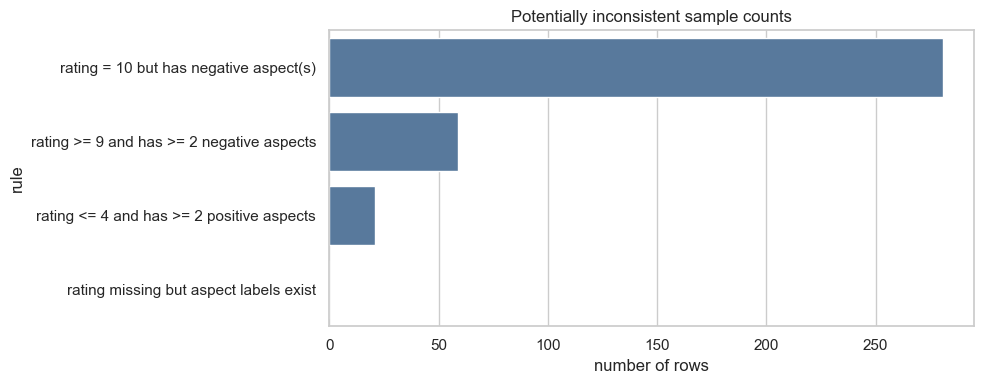

In [7]:
plt.figure(figsize=(10, 4))
sns.barplot(data=qc_summary, x="count", y="rule", color="#4c78a8")
plt.title("Potentially inconsistent sample counts")
plt.xlabel("number of rows")
plt.ylabel("rule")
plt.tight_layout()
plt.show()

In [8]:
def aspects_with_label(row, label_value):
    return [col.replace("_label", "") for col in aspect_cols_train if row[col] == label_value]

inconsistent_mask = rule_high10_neg | rule_high9_many_neg | rule_low4_many_pos | rule_missing_rating_with_labels
inconsistent_examples = qc_df.loc[
    inconsistent_mask,
    [
        "Review",
        "rating",
        "neg_aspect_count",
        "pos_aspect_count",
        "mentioned_aspect_count",
    ] + aspect_cols_train,
].copy()

if inconsistent_examples.empty:
    print("No inconsistent samples were detected under the current rules.")
else:
    idx = inconsistent_examples.index
    inconsistent_examples["rule_tag"] = np.select(
        [
            rule_high10_neg.loc[idx],
            rule_high9_many_neg.loc[idx],
            rule_low4_many_pos.loc[idx],
            rule_missing_rating_with_labels.loc[idx],
        ],
        [
            "rating=10 + negative aspect",
            "rating>=9 + many negative aspects",
            "rating<=4 + many positive aspects",
            "rating missing + has aspect labels",
        ],
        default="other",
    )
    inconsistent_examples["negative_aspects"] = inconsistent_examples.apply(lambda row: aspects_with_label(row, 2), axis=1)
    inconsistent_examples["positive_aspects"] = inconsistent_examples.apply(lambda row: aspects_with_label(row, 1), axis=1)
    inconsistent_examples["review_preview"] = (inconsistent_examples["Review"].astype(str).str.slice(0, 220))

    inconsistent_examples = inconsistent_examples.reset_index().rename(columns={"index": "row_id"})

    cols_show = [
        "row_id",
        "rating",
        "neg_aspect_count",
        "pos_aspect_count",
        "rule_tag",
        "negative_aspects",
        "positive_aspects",
        "review_preview",
    ]

    print("Top 10 inconsistent samples for manual review:")
    display(inconsistent_examples[cols_show].sort_values(["neg_aspect_count", "pos_aspect_count"], ascending=[False, False]).head(10))

Top 10 inconsistent samples for manual review:


,row_id,rating,neg_aspect_count,pos_aspect_count,rule_tag,negative_aspects,positive_aspects,review_preview
256,9557,3.0,4,2,rating<=4 + many positive aspects,"[vệ sinh, khách sạn, phòng ốc, dịch vụ]","[đồ ăn thức uống, vị trí]",trải_nghiệm tệ ga trải giường không được thay ...
132,4319,4.0,3,2,rating<=4 + many positive aspects,"[vệ sinh, khách sạn, phòng ốc]","[vị trí, dịch vụ]",tôi muốn hỏi ai là người đánh_giá điểm 9 1 trê...
217,7515,9.0,3,2,rating>=9 + many negative aspects,"[vệ sinh, đồ ăn thức uống, phòng ốc]","[khách sạn, vị trí]",thiết_kế tổng_thể dễ_thương và độc_đáo vị_trí ...
228,8089,4.0,3,2,rating<=4 + many positive aspects,"[vệ sinh, đồ ăn thức uống, dịch vụ]","[vị trí, phòng ốc]",phòng khách_sạn đẹp tiện_nghi phòng tốt giá rẻ...
268,10290,10.0,3,2,rating=10 + negative aspect,"[đồ ăn thức uống, khách sạn, dịch vụ]","[vệ sinh, vị trí]",ưu_điểm sạch_sẽ gần biển nhược_điểm buổi sáng ...
110,3703,9.0,3,1,rating>=9 + many negative aspects,"[đồ ăn thức uống, khách sạn, dịch vụ]",[vị trí],nhân_viên ở đây không thân_thiện như ở những n...
29,1217,10.0,3,0,rating=10 + negative aspect,"[vệ sinh, khách sạn, phòng ốc]",[],bể_bơi bị hỏng và bẩn đầy những mảnh nhựa nhỏ ...
195,6790,9.0,2,4,rating>=9 + many negative aspects,"[vệ sinh, phòng ốc]","[đồ ăn thức uống, khách sạn, vị trí, dịch vụ]",khách_sạn chỉ có hai tầng và không có thang_má...
39,1458,9.0,2,3,rating>=9 + many negative aspects,"[khách sạn, phòng ốc]","[vệ sinh, vị trí, dịch vụ]",khách_sạn gần biển chú bé nhiệt_tình nhân_viên...
47,1798,10.0,2,3,rating=10 + negative aspect,"[vệ sinh, phòng ốc]","[khách sạn, vị trí, dịch vụ]",chỗ nghỉ dễ tìm và giá_cả phải_chăng nếu bạn đ...


- **Rule-Based Anomaly Detection:** Validation checks flagged a small percentage of samples for label inconsistencies between the overall rating and aspect-level sentiments.
   - **High Rating / Negative Aspects:** The most common anomaly involves high overall ratings containing negative aspect labels (281 samples, 2.125%).
   - **Extreme Edge Cases:** Smaller subsets include ratings ≥ 9 with multiple negative labels (59 samples, 0.446%) and ratings ≤ 4 with multiple positive labels (21 samples, 0.159%).
- **Manual Verification:** Qualitative inspection of representative samples confirms that the vast majority of these are not labeling errors (noisy labels).
- **Root Cause (Mixed Sentiment):** The perceived inconsistencies naturally stem from mixed-sentiment reviews. Users frequently assign a high or low overall rating while explicitly praising or criticizing specific, granular aspects within the review text.

## Descriptive statistics for the rating column

============================== Rating statistics ==============================


,metric,value
0,count,13224.000000
1,mean,8.605717
2,median,9.000000
3,variance,3.365213
4,min,2.000000
5,max,10.000000
6,Q1,8.000000
7,Q3,10.000000
8,IQR,2.000000


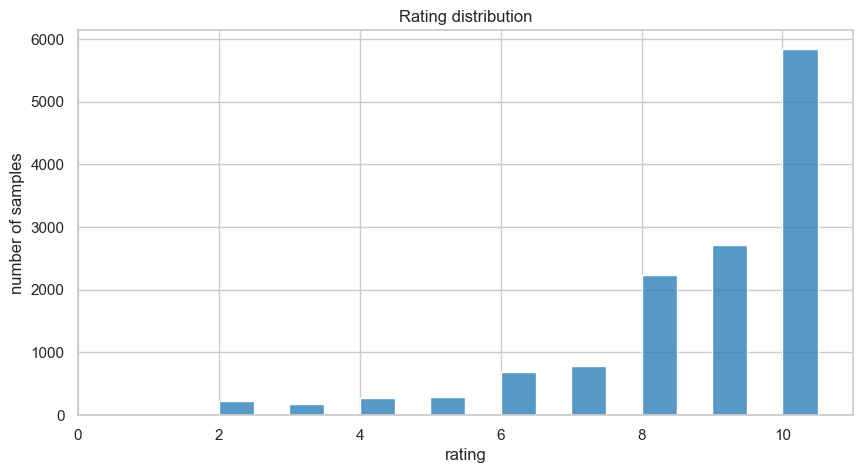

In [9]:
rating_series = pd.to_numeric(df_train[rating_col], errors="coerce")

q1 = rating_series.quantile(0.25)
q3 = rating_series.quantile(0.75)
iqr = q3 - q1

rating_stats = pd.DataFrame(
    {
        "metric": [
            "count",
            "mean",
            "median",
            "variance",
            "min",
            "max",
            "Q1",
            "Q3",
            "IQR",
        ],
        "value": [
            rating_series.count(),
            rating_series.mean(),
            rating_series.median(),
            rating_series.var(),
            rating_series.min(),
            rating_series.max(),
            q1,
            q3,
            iqr,
        ],
    }
)

print("="*30 + " Rating statistics " + "="*30)
display(rating_stats)

plt.figure(figsize=(10, 5))
sns.histplot(rating_series.dropna(), bins=np.arange(0.5, 10.6, 0.5), color="#1f77b4")
plt.title("Rating distribution")
plt.xlabel("rating")
plt.ylabel("number of samples")
plt.show()

- A mean of 8.61 and a median of 9.0 indicate that the ratings are overwhelmingly positive.
- With Q1 = 8 and Q3 = 10, 50% of the reviews fall within the 8-10 range.
- The histogram shows that the majority of samples are clustered between 8 and 10, with a score of 10 being the most frequent.
- Low scores (2-6) are very rare, resulting in a left-skewed distribution towards higher scores, which indicates a strong positive bias in the data.

## Label distribution by aspect and class imbalance check

============================== Aspect label distribution (count) ==============================


class,0,1,2
aspect,,,
dịch vụ_label,6897,5782,545
khách sạn_label,3108,9074,1042
phòng ốc_label,7655,3914,1655
vệ sinh_label,9309,3155,760
vị trí_label,8436,4507,281
đồ ăn thức uống_label,10960,1731,533


============================== Aspect label distribution (percentage) ==============================


class,0,1,2
aspect,,,
dịch vụ_label,52.155,43.724,4.121
khách sạn_label,23.503,68.618,7.880
phòng ốc_label,57.887,29.598,12.515
vệ sinh_label,70.395,23.858,5.747
vị trí_label,63.793,34.082,2.125
đồ ăn thức uống_label,82.880,13.090,4.031


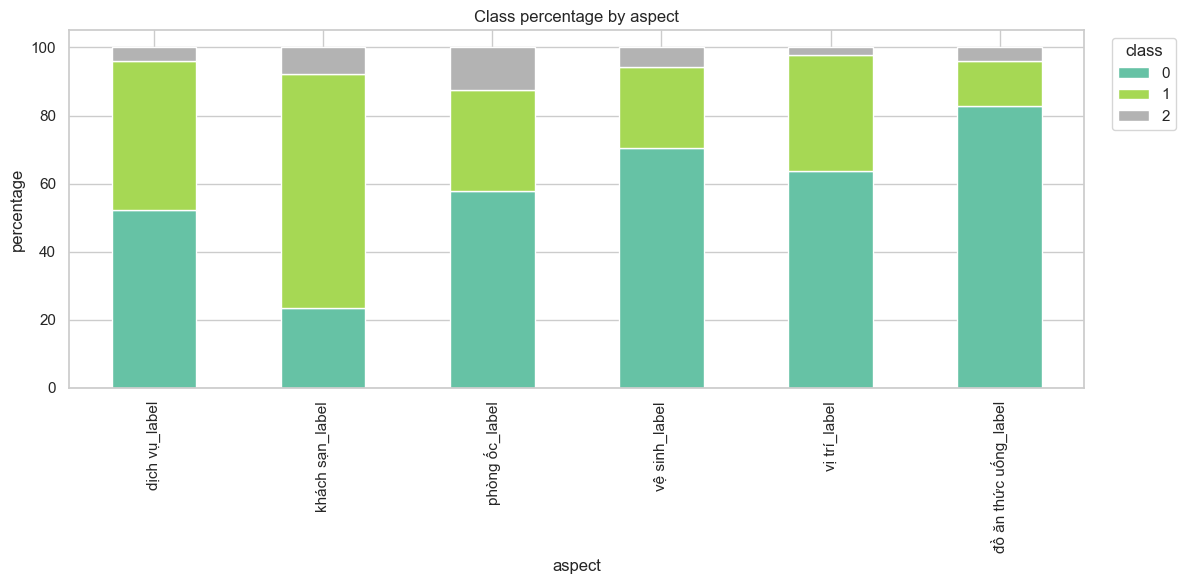

In [10]:
records = []

for col in aspect_cols:
    counts = df_train[col].value_counts(dropna=False).sort_index()
    total = counts.sum()
    pct = (counts / total * 100).round(3)

    for cls, cnt in counts.items():
        records.append({"aspect": col, "class": cls, "count": int(cnt), "pct": pct.loc[cls]})

label_dist_df_train = pd.DataFrame(records)

pct_pivot = label_dist_df_train.pivot(index="aspect", columns="class", values="pct").fillna(0)
count_pivot = label_dist_df_train.pivot(index="aspect", columns="class", values="count").fillna(0)

print("="*30 + " Aspect label distribution (count) " + "="*30)
display(count_pivot)
print("="*30 + " Aspect label distribution (percentage) " + "="*30)
display(pct_pivot)

ax = pct_pivot.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")
ax.set_title("Class percentage by aspect")
ax.set_ylabel("percentage")
ax.set_xlabel("aspect")
ax.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

- **Mention Frequency:** The most discussed aspects are the Hotel (76.5%), Service (47.8%), and Room (42.1%), while Food & Beverage (F&B) is the least mentioned (17.1%).
- **Top Strengths:** User satisfaction is exceptionally high for the general Hotel experience (68.62% positive), Service (43.72%), and Location (34.08%).
- **Major Pain Points:** The Room is the primary weakness, holding the highest negative rate both overall (12.5%).
- **Data Sparsity (Class 0):** A dominant 'class 0' across multiple categories indicates a high volume of generic reviews that lack aspect-specific details.

## Text EDA - token length and max_length suggestion

============================== Review length statistics (token count) ==============================


,metric,value
0,count,13224.000000
1,min,3.000000
2,max,205.000000
3,mean,30.991001
4,median,23.000000
5,p90,63.000000
6,p95,86.000000
7,p99,164.770000
8,max,205.000000


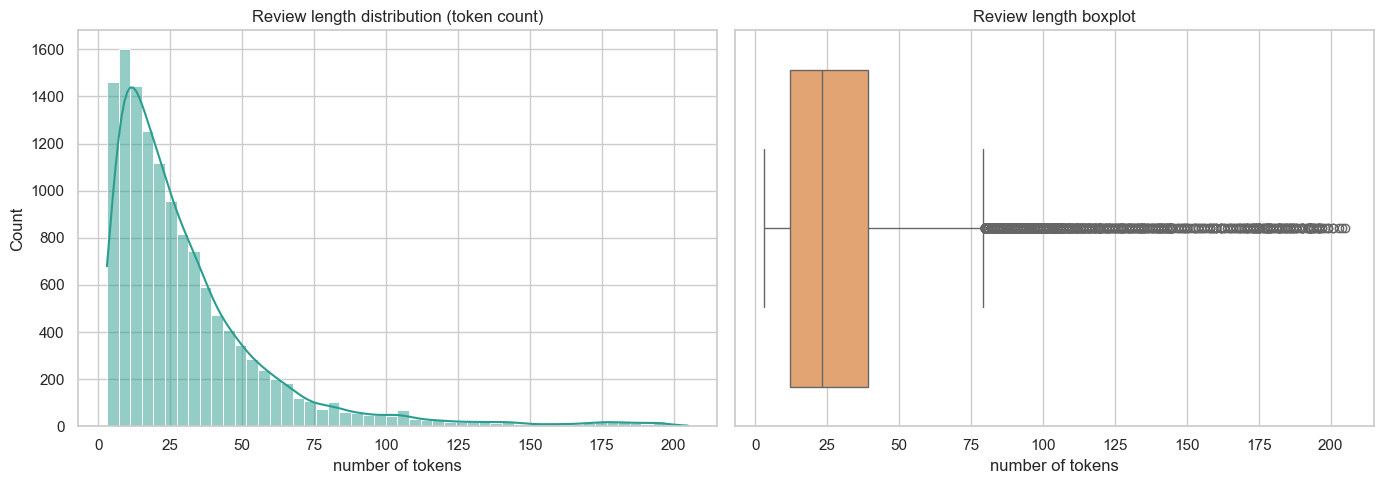

In [11]:
reviews = df_train[review_col].fillna("").astype(str)
token_lists = reviews.str.split()
token_lengths = token_lists.map(len)

def round_up(value: float, base: int = 8) -> int:
    if value <= 0:
        return base
    return int(base * np.ceil(value / base))

length_stats = pd.DataFrame(
    {
        "metric": ["count", "min", "max", "mean", "median", "p90", "p95", "p99", "max"],
        "value": [
            token_lengths.count(),
            token_lengths.min(),
            token_lengths.max(),
            token_lengths.mean(),
            token_lengths.median(),
            token_lengths.quantile(0.90),
            token_lengths.quantile(0.95),
            token_lengths.quantile(0.99),
            token_lengths.max(),
        ],
    }
)
print("="*30 + " Review length statistics (token count) " + "="*30)
display(length_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(token_lengths, bins=50, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Review length distribution (token count)")
axes[0].set_xlabel("number of tokens")

sns.boxplot(x=token_lengths, ax=axes[1], color="#f4a261")
axes[1].set_title("Review length boxplot")
axes[1].set_xlabel("number of tokens")

plt.tight_layout()
plt.show()

## Keyword frequency (overall and by aspect)

In [12]:
with open('vietnamese-stopwords.txt', encoding='utf-8') as f:
    STOPWORDS = set(line.strip() for line in f if line.strip())

special_token_pattern = re.compile(r"[^\w]", flags=re.UNICODE)

def normalize_token(token):
    token = token.lower().strip()
    token = special_token_pattern.sub("", token)
    return token

def extract_tokens(text):
    tokens = []
    for token in text.split():
        token = normalize_token(token)
        if not token:
            continue
        if token in STOPWORDS:
            continue
        if token.isdigit():
            continue
        if len(token) < 2:
            continue
        tokens.append(token)
    return tokens

def top_tokens_from_series(text_series, top_n=20):
    counter = Counter()
    for text in text_series.fillna("").astype(str):
        counter.update(extract_tokens(text))
    top_items = counter.most_common(top_n)
    return pd.DataFrame(top_items, columns=["token", "count"])

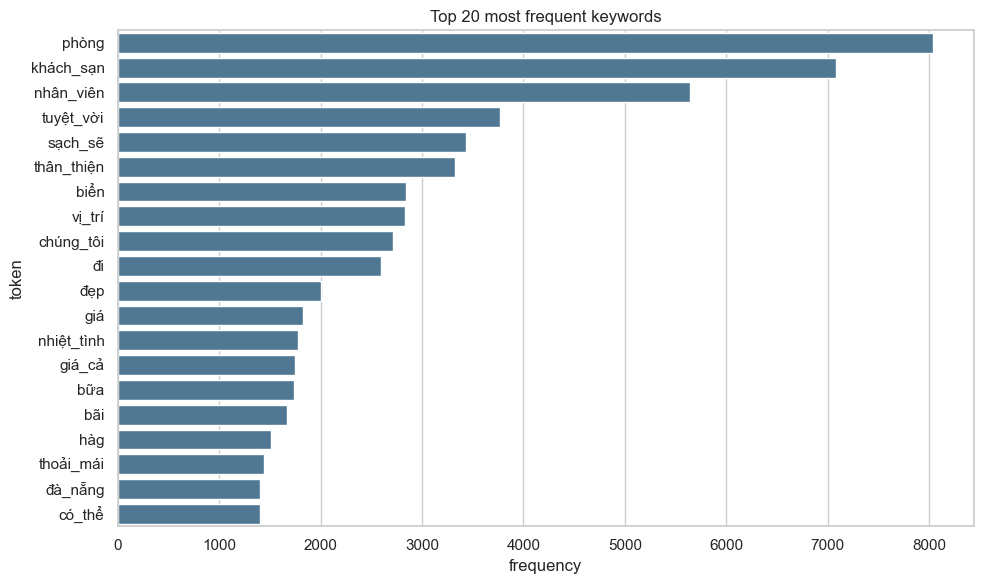

In [13]:
# Top keywords in the full training set
overall_top = top_tokens_from_series(reviews, top_n=25)

plt.figure(figsize=(10, 6))
sns.barplot(data=overall_top.head(20), x="count", y="token", color="#457b9d")
plt.title("Top 20 most frequent keywords")
plt.xlabel("frequency")
plt.ylabel("token")
plt.tight_layout()
plt.show()

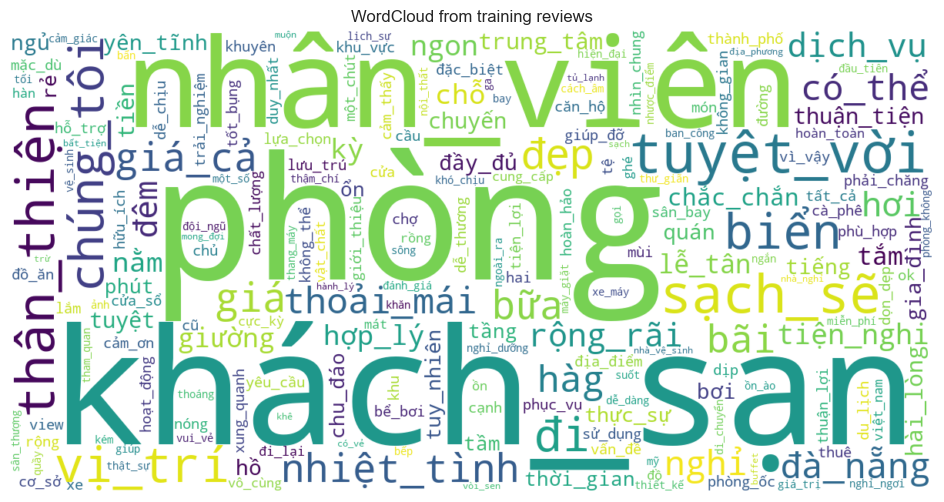

In [14]:
# WordCloud is optional and should not break the notebook if unavailable
try:
    wc_text = " ".join([" ".join(extract_tokens(text)) for text in reviews])
    wc = WordCloud(width=1200, height=600, background_color="white", collocations=False).generate(wc_text)

    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud from training reviews")
    plt.show()
except Exception as exc:
    print("WordCloud generation skipped (package may not be installed).")
    print(f"Details: {exc}")

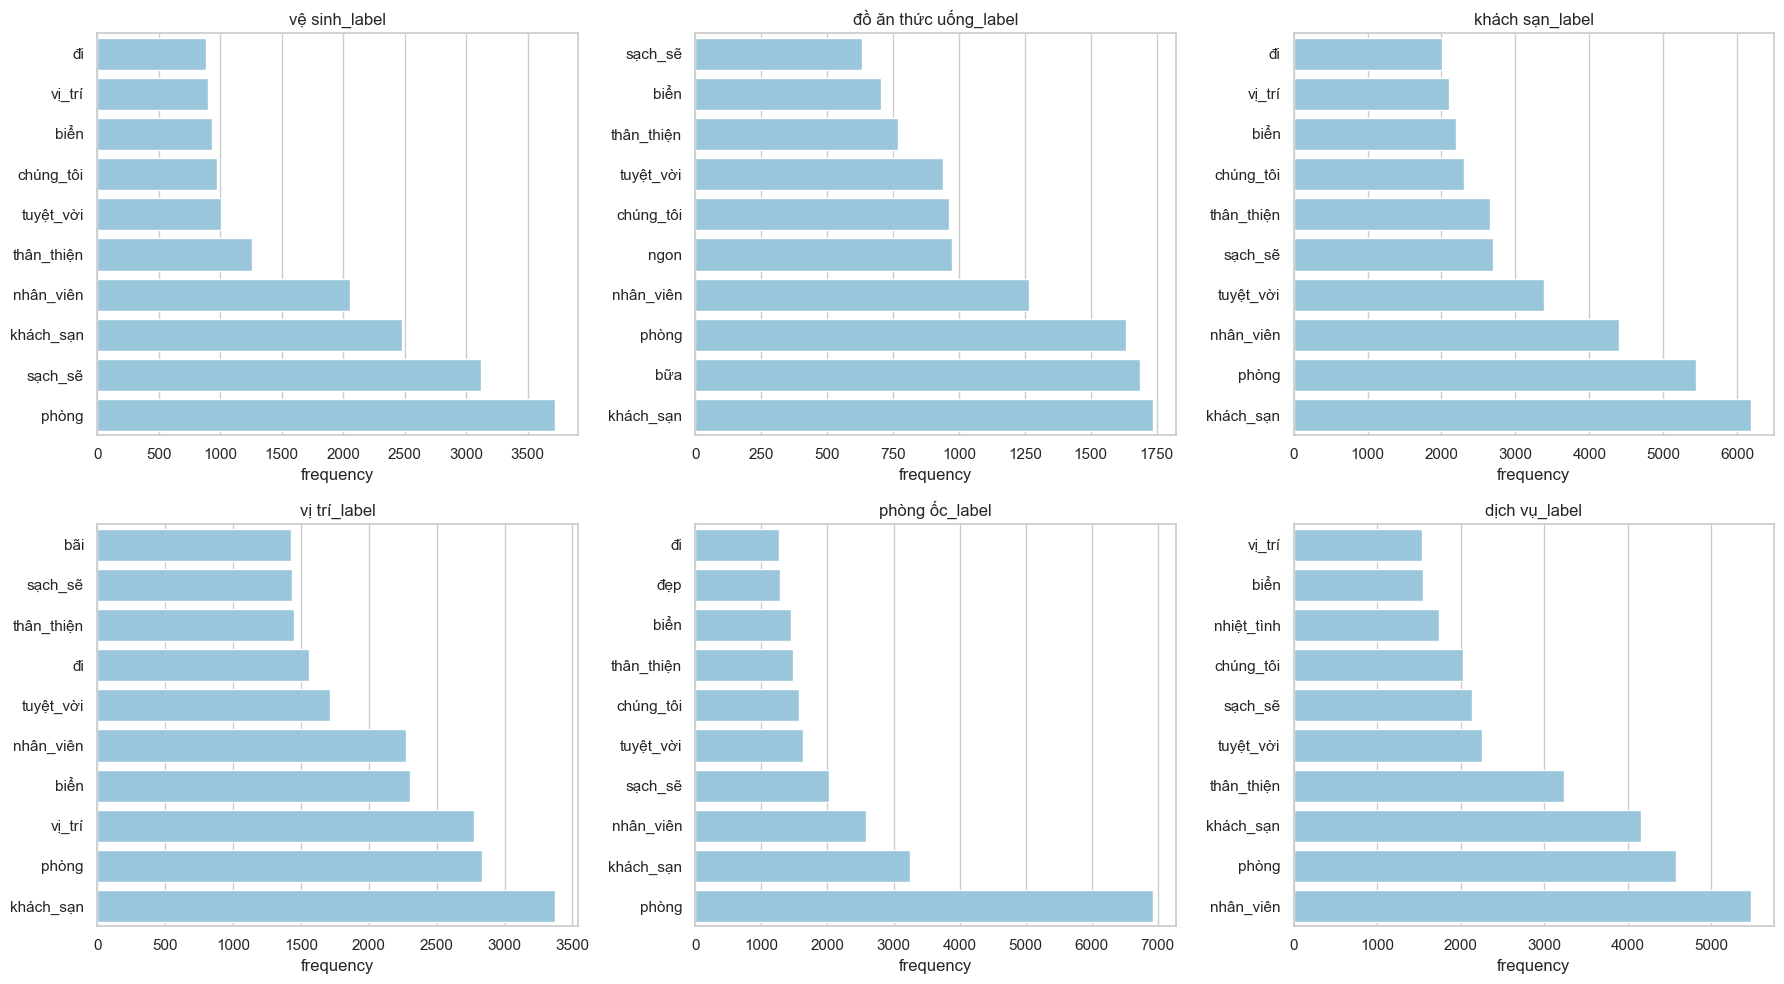

In [15]:
# Top keywords by aspect (filter rows where aspect label != 0)
aspect_top_map = {}
for col in aspect_cols:
    subset = df_train.loc[df_train[col] != 0, review_col]
    top_df_train = top_tokens_from_series(subset, top_n=10)
    aspect_top_map[col] = top_df_train

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, col in enumerate(aspect_cols[:6]):
    data_plot = aspect_top_map[col].sort_values("count", ascending=True)
    sns.barplot(data=data_plot, x="count", y="token", ax=axes[idx], color="#8ecae6")
    axes[idx].set_title(col)
    axes[idx].set_xlabel("frequency")
    axes[idx].set_ylabel("")

for ax in axes[len(aspect_cols[:6]):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

- **Positive Stay-Centric Focus:** The word cloud and dominant keywords (e.g., phòng, khách_sạn, nhân_viên, sạch_sẽ, tuyệt_vời) show that the reviews primarily revolve around the core accommodation experience and hold a strong positive sentiment.

- **Feature Overlap:** There is noticeable keyword overlap across different aspects, suggesting a degree of content correlation or semantic overlap between categories that should be considered during model analysis.

## Special Character & Punctuation Analysis

In [16]:
all_text_combined = ''.join(df_train['Review'].astype(str).tolist())
char_counter = Counter(all_text_combined)

vn_chars = set('aàáảãạăắằẳẵặâấầẩẫậbcdđeèéẻẽẹêếềểễệfghiìíỉĩịjklmnoòóỏõọôốồổỗộơớờởỡợpqrstuùúủũụưứừửữựvwxyỳýỷỹỵz')
vn_upper = set(c.upper() for c in vn_chars)

special_chars = {}
digits_count = {}
punctuation_count = {}

for char, count in char_counter.items():
    if char.isdigit():
        digits_count[char] = count
    elif char in string.punctuation or char in '\u201c\u201d\u2018\u2019\u2026\u2013\u2014\u2022\u00b7':
        punctuation_count[char] = count
    elif char.lower() not in vn_chars and char not in vn_upper and char != ' ':
        special_chars[char] = count

print("CHARACTER ANALYSIS")
print("=" * 60)
print(f"Total characters: {len(all_text_combined):,}")
print(f"Unique characters: {len(char_counter)}")

print(f"\nDIGITS:")
for char, count in sorted(digits_count.items(), key=lambda x: -x[1]):
    print(f"   '{char}': {count:>6,} times")

print(f"\nPUNCTUATION:")
for char, count in sorted(punctuation_count.items(), key=lambda x: -x[1]):
    print(f"   '{char}': {count:>6,} times")

print(f"\nSPECIAL / UNUSUAL CHARACTERS:")
for char, count in sorted(special_chars.items(), key=lambda x: -x[1]):
    print(f"   '{char}' (U+{ord(char):04X}): {count:>6,} times")

CHARACTER ANALYSIS
Total characters: 2,235,922
Unique characters: 105

DIGITS:
   '0':  1,848 times
   '1':  1,456 times
   '2':  1,140 times
   '5':    789 times
   '3':    666 times
   '4':    466 times
   '6':    192 times
   '7':    166 times
   '8':    124 times
   '9':    116 times

PUNCTUATION:
   '_': 111,524 times

SPECIAL / UNUSUAL CHARACTERS:


- **High Data Cleanliness:** The text corpus is exceptionally clean, comprising 2,235,922 total characters but only 105 unique ones, with no significant presence of "special" or unusual characters.

- **Valid Tokenization Markers:** The high frequency of underscores (111,524) is a standard, expected result of Vietnamese word segmentation (e.g., khách_sạn, tuyệt_vời) and does not represent punctuation noise.

- **Minimal Numerical Noise:** Digits are present but at a very low frequency relative to the overall corpus, ensuring numerical data does not overshadow the linguistic text.